In [5]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import torch

In [6]:
# Data
training_data_path = 'data/lorenz_training.npy'
training_data = np.load(training_data_path)
print(training_data.shape)

truth_data_path = 'data/lorenz_truth.npy'
truth_data = np.load(truth_data_path)
print(truth_data.shape)

(5001, 3)
(5000, 3)


In [314]:
# Define a simple MLP (Multi-Layer Perceptron) for Lorenz system prediction
class LorenzMLP(torch.nn.Module):
    def __init__(self, input_size=3, hidden_size=1024, output_size=3, num_layers=4):
        super(LorenzMLP, self).__init__()
        
        # Input layer
        layers = [torch.nn.Linear(input_size, hidden_size), 
                 torch.nn.GELU()]
        
        # Hidden layers
        for _ in range(num_layers - 2):
            layers.extend([
                torch.nn.Linear(hidden_size, hidden_size),
                torch.nn.GELU()
            ])
        
        # Output layer
        layers.append(torch.nn.Linear(hidden_size, output_size))
        
        # Sequential container
        self.model = torch.nn.Sequential(*layers)
    
    def forward(self, x):
        return x + self.model(x)

In [315]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert data to PyTorch tensors
X_train = torch.tensor(training_data[:-1], dtype=torch.float32).to(device)
y_train = torch.tensor(training_data[1:], dtype=torch.float32).to(device)

print(f"Input shape: {X_train.shape}, Target shape: {y_train.shape}")

X_truth = torch.tensor(truth_data[:-1], dtype=torch.float32).to(device)
y_truth = torch.tensor(truth_data[1:], dtype=torch.float32).to(device)

model = LorenzMLP().to(device)

Input shape: torch.Size([5000, 3]), Target shape: torch.Size([5000, 3])


In [316]:
# Define loss function and optimizer
criterion = torch.nn.MSELoss()

# Define optimizer with AdamW instead of Adam
lr = 1e-4
min_lr = 1e-7
weight_decay = 1e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Define cosine annealing learning rate scheduler
num_epochs = 5000  # Define total number of epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)


Starting training...
Epoch [100/5000], Train Loss: 0.045198, Val Loss: 0.033741, LR: 0.000100
Epoch [200/5000], Train Loss: 0.012352, Val Loss: 0.010020, LR: 0.000100
Epoch [300/5000], Train Loss: 0.010383, Val Loss: 0.016328, LR: 0.000099
Epoch [400/5000], Train Loss: 0.006515, Val Loss: 0.006301, LR: 0.000098
Epoch [500/5000], Train Loss: 0.004404, Val Loss: 0.006057, LR: 0.000098
Epoch [600/5000], Train Loss: 0.003804, Val Loss: 0.005819, LR: 0.000096
Epoch [700/5000], Train Loss: 0.003276, Val Loss: 0.004979, LR: 0.000095
Epoch [800/5000], Train Loss: 0.003238, Val Loss: 0.005144, LR: 0.000094
Epoch [900/5000], Train Loss: 0.002742, Val Loss: 0.004572, LR: 0.000092
Epoch [1000/5000], Train Loss: 0.002563, Val Loss: 0.004366, LR: 0.000090
Epoch [1100/5000], Train Loss: 0.002389, Val Loss: 0.004350, LR: 0.000089
Epoch [1200/5000], Train Loss: 0.002977, Val Loss: 0.005603, LR: 0.000086
Epoch [1300/5000], Train Loss: 0.002179, Val Loss: 0.004256, LR: 0.000084
Epoch [1400/5000], Train L

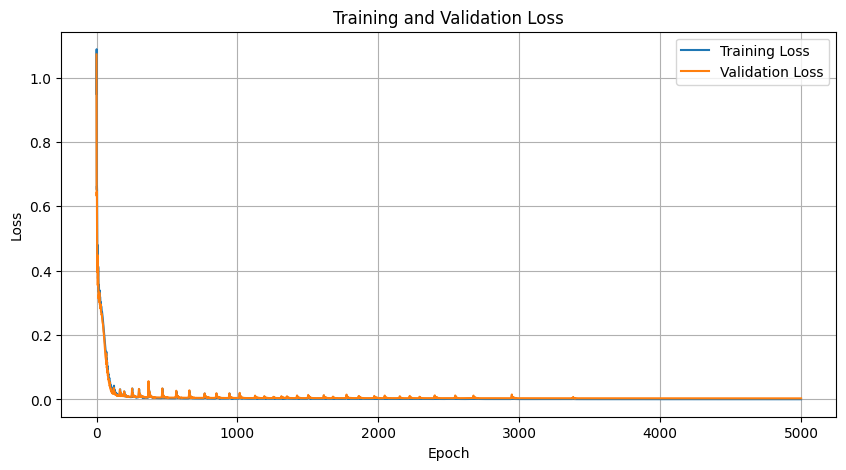

In [317]:
# Training loop
train_losses = []  # To track the training loss values
valid_losses = []  # To track the validation loss values
best_loss = float('inf')
best_model_state = None

print("Starting training...")
for epoch in range(num_epochs):
    # Set model to training mode
    model.train()
    
    # Forward pass on training data
    outputs = model(X_train)
    train_loss = criterion(outputs, y_train)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    
    # Update learning rate
    scheduler.step()
    
    # Evaluate on validation set (truth data)
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_truth)
        val_loss = criterion(val_outputs, y_truth)
    
    # Save losses for plotting
    train_losses.append(train_loss.item())
    valid_losses.append(val_loss.item())
    
    # Save best model based on validation loss
    if val_loss.item() < best_loss:
        best_loss = val_loss.item()
        best_model_state = model.state_dict().copy()
    
    # Print progress
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss.item():.6f}, Val Loss: {val_loss.item():.6f}, LR: {scheduler.get_last_lr()[0]:.6f}')

# Load best model
model.load_state_dict(best_model_state)
print(f"Training completed. Best validation loss: {best_loss:.6f}")

# Plot the loss curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [318]:
ic = y_train[-1].to(device)
ic.reshape(1, 3)

tensor([[-0.5452, -4.0867, 33.0516]], device='cuda:0')

In [319]:
pred = torch.zeros(5000, 3).to(device)
for i in range(5000):
    pred[i] = model(ic)
    ic = pred[i]

In [320]:
# Convert tensor to numpy array and save to file
pred_np = pred.detach().cpu().numpy()
np.save('pred_trajectory3.npy', pred_np)  # This will save as a 5000x3 numpy array
pred  # Display the tensor as before

tensor([[-0.8550, -4.0973, 32.2678],
        [-1.1415, -4.1360, 31.5157],
        [-1.4096, -4.2052, 30.7934],
        ...,
        [ 4.8383,  8.9391, 22.8439],
        [ 5.2384,  9.7179, 22.7715],
        [ 5.6742, 10.5722, 22.7851]], device='cuda:0', grad_fn=<CopySlices>)

In [321]:
# k=20 # number of snapshots to test for short time 
# modes = 100

# SCORING FOR SHORT-TIME AND LONG-TIME FORECASTS OF ODES
def scoring_lorenz(truth, prediction, k=20, modes=100):
    '''produce long-time and short-time error scores.'''
    [m,n]=truth.shape
    Est = np.linalg.norm(truth[:,0:k]-prediction[:,0:k],2)/np.linalg.norm(truth[:,0:k],2)

    yt = truth[-modes:, :]
    M = np.arange(-30, 31, 1)
    M2 = np.arange(0, 71, 1)
    yhistxt, xhistx = np.histogram(yt[:, 0], bins=M)
    yhistyt, xhisty = np.histogram(yt[:, 1], bins=M)
    yhistzt, xhistz = np.histogram(yt[:, 2], bins=M2)

    yp = prediction[-modes:, :]
    yhistxp, xhistx = np.histogram(yp[:, 0], bins=M)
    yhistyp, xhisty = np.histogram(yp[:, 1], bins=M)
    yhistzp, xhistz = np.histogram(yp[:, 2], bins=M2)
    
    Eltx = np.linalg.norm(yhistxt-yhistxp,2)/np.linalg.norm(yhistxt,2)
    Elty = np.linalg.norm(yhistyt-yhistyp,2)/np.linalg.norm(yhistyt,2)
    Eltz = np.linalg.norm(yhistzt-yhistzp,2)/np.linalg.norm(yhistzt,2)
    
    Elt =  (Eltx+Elty+Eltz)/3
    
    E1 = 100*(1-Est)
    E2 = 100*(1-Elt)

    if np.isnan(E1):
        E1 = -np.inf
    if np.isnan(E2):
        E2 = -np.inf
    
    return E1, E2

In [322]:
scoring_lorenz(truth_data, pred_np)

(np.float64(50.42844821424979), np.float64(-2.31062928830037))